# 250213 R - Fresnel Equations phase shifts




In [1]:
%matplotlib widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def funcPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[])
    line02, = ax0.plot([],[])
    line03, = ax0.plot([],[])
    line04, = ax0.plot([],[])
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend(['rperp','tperp', 'rpara', 'tpara'],)
    def plot(ni=1, nt=1.5):
        output1 = func1(ni, nt, thi)
        output2 = func2(ni, nt, thi)
        output3 = func3(ni, nt, thi)
        output4 = func4(ni, nt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(1,5,.1), nt=(1,5,.1))

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, thi):
    return(arcsin(ni/nt*sin(thi)))

def rperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    tht = snells(ni, nt, thi)
    
    return((ni/mui*cos(thi)-nt/mut*cos(tht))/(ni/mui*cos(thi)+nt/mut*cos(tht)))

def tperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light perpendicular to the 
    plane of incidence and therefore parallel to the interface
    of the material.

    this is S-polarized in the nomenclature of optics
    '''

    tht = snells(ni, nt, thi)

    return((2*ni/mui*cos(thi))/(ni/mui*cos(thi)+nt/mut*cos(tht)))

def rpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    reflection coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    tht = snells(ni, nt, thi)
    
    return((nt/mut*cos(thi)-ni/mui*cos(tht))/(ni/mui*cos(tht)+nt/mut*cos(thi)))

def tpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
   
    tht = snells(ni, nt, thi)

    return((2*ni/mui*cos(thi))/(ni/mui*cos(tht)+nt/mut*cos(thi)))

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0, min=1.0), FloatSlider(value=1.5, descr…

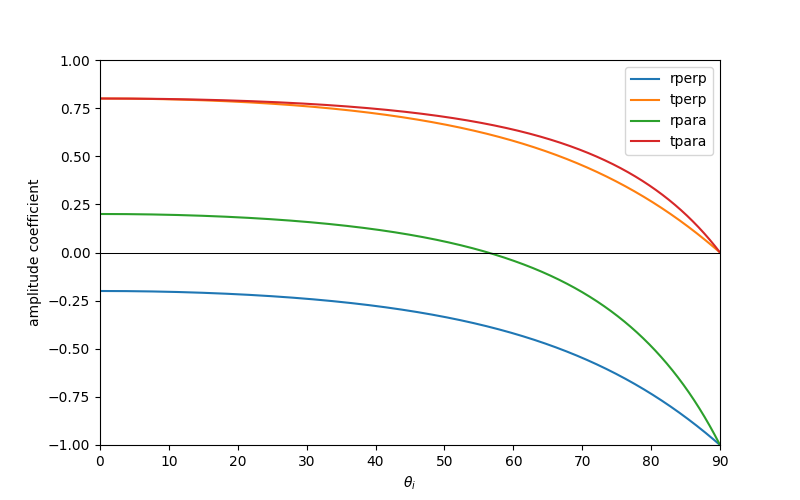

In [3]:
funcPlot(rperp, tperp, rpara, tpara)

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0, min=1.0), FloatSlider(value=1.5, descr…

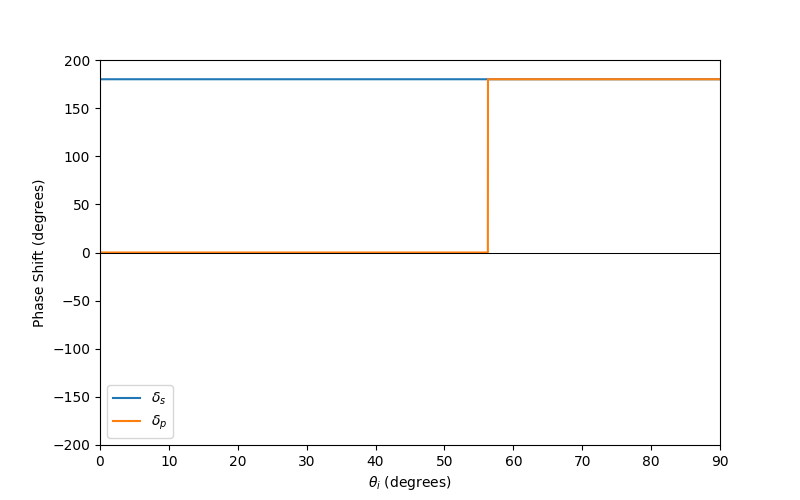

In [4]:
def funcPlotPhase(func1, func2):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1, 89.9, 10000)
    line01, = ax0.plot([],[])
    line02, = ax0.plot([],[])
    ax0.set_xlim((0, 90))
    ax0.set_ylim((-200, 200))  # Phase shift in degrees
    ax0.axhline(0, linewidth=0.75, color='k')
    ax0.set_xlabel(r'$\theta_i$ (degrees)')
    ax0.set_ylabel('Phase Shift (degrees)')
    ax0.legend([r'$\delta_s$', r'$\delta_p$'])

    def plot(ni=1, nt=1.5):
        output1 = func1(ni, nt, thi)  # Phase shift for r_s
        output2 = func2(ni, nt, thi)  # Phase shift for r_p
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        plt.draw()
    
    interact(plot, ni=(1, 5, 0.1), nt=(1, 5, 0.1))

def phase_rperp(ni, nt, thi, mui=8.85e-12, mut=8.85e-12):
    """Computes phase shift (in degrees) of r_s (s-polarized reflection)."""
    tht = snells(ni, nt, thi)
    r_s = (ni/mui*cos(thi) - nt/mut*cos(tht)) / (ni/mui*cos(thi) + nt/mut*cos(tht))
    return np.angle(r_s, deg=True)  # Convert phase shift to degrees

def phase_rpara(ni, nt, thi, mui=8.85e-12, mut=8.85e-12):
    """Computes phase shift (in degrees) of r_p (p-polarized reflection)."""
    tht = snells(ni, nt, thi)
    r_p = (nt/mut*cos(thi) - ni/mui*cos(tht)) / (ni/mui*cos(tht) + nt/mut*cos(thi))
    return np.angle(r_p, deg=True)  # Convert phase shift to degrees

# Call the function to plot phase shifts
funcPlotPhase(phase_rperp, phase_rpara)
